<a href="https://colab.research.google.com/github/yug1303/Credit_card/blob/main/Copy_of_Credit_Card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#Data Loading and Preprocessing

In [ ]:
#Uploading dataset to Google Colab
from google.colab import files
uploaded = files.upload()

Saving train_dataset_final1.csv to train_dataset_final1 (1).csv


In [ ]:
#Peek into the dataset
df = pd.read_csv('train_dataset_final1.csv')
df.head()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [ ]:
#Create a copy of the raw dataset
df_raw=df.copy()

In [ ]:
# Shape of the dataset
print("Shape of dataset:", df.shape)

# Data types and non-null counts
df.info()


Shape of dataset: (25247, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25247 entries, 0 to 25246
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         25247 non-null  int64  
 1   marriage            25247 non-null  int64  
 2   sex                 25247 non-null  int64  
 3   education           25247 non-null  int64  
 4   LIMIT_BAL           25247 non-null  int64  
 5   age                 25121 non-null  float64
 6   pay_0               25247 non-null  int64  
 7   pay_2               25247 non-null  int64  
 8   pay_3               25247 non-null  int64  
 9   pay_4               25247 non-null  int64  
 10  pay_5               25247 non-null  int64  
 11  pay_6               25247 non-null  int64  
 12  Bill_amt1           25247 non-null  float64
 13  Bill_amt2           25247 non-null  float64
 14  Bill_amt3           25247 non-null  float64
 15  Bill_amt4           252

since 'Age' has null values we will impute those rows with median value of age.

---



In [ ]:
median_age = df['age'].median()
df['age'].fillna(median_age, inplace=True)


<ipython-input-40-528900305>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)


In [ ]:
df['sex'].value_counts()

,count
sex,
1,15252
0,9995


In [ ]:
df['education'].value_counts()

,count
education,
2,11717
1,8988
3,4115
5,253
4,116
6,44
0,14


From the value counts of education we can find that there are three unlabelled categories 0,5,6. We will now convert these to 4 (Others Category)

In [ ]:
df['education'] = df['education'].replace({0: 4, 5: 4, 6: 4})

This column is now cleaned.

In [ ]:
df['marriage'].value_counts()

,count
marriage,
2,13441
1,11480
3,273
0,53


Similarly for Marriage, there is an extra value of 0 which we'll replace by 3 (Others Category)

In [ ]:
df['marriage'] = df['marriage'].replace(0, 3)

Marriage column is also now cleaned.

# Exploratory Data Analysis

In [ ]:
print("Shape:", df.shape)

Shape: (25247, 27)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25247 entries, 0 to 25246
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         25247 non-null  int64  
 1   marriage            25247 non-null  int64  
 2   sex                 25247 non-null  int64  
 3   education           25247 non-null  int64  
 4   LIMIT_BAL           25247 non-null  int64  
 5   age                 25247 non-null  float64
 6   pay_0               25247 non-null  int64  
 7   pay_2               25247 non-null  int64  
 8   pay_3               25247 non-null  int64  
 9   pay_4               25247 non-null  int64  
 10  pay_5               25247 non-null  int64  
 11  pay_6               25247 non-null  int64  
 12  Bill_amt1           25247 non-null  float64
 13  Bill_amt2           25247 non-null  float64
 14  Bill_amt3           25247 non-null  float64
 15  Bill_amt4           25247 non-null  float64
 16  Bill

In [ ]:
df.describe()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
count,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,...,25247.000000,25247.000000,2.524700e+04,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000
mean,17640.000000,1.558205,0.604111,1.840813,168342.060443,35.431022,-0.042857,-0.159544,-0.190359,-0.241415,...,38806.221029,5718.624966,6.047352e+03,5288.910651,4865.960834,4906.766828,5270.499287,44859.647485,0.362962,0.190399
std,7288.325459,0.521965,0.489050,0.749217,129892.784807,9.152635,1.099315,1.173990,1.172636,1.146753,...,59182.792531,16806.842125,2.400962e+04,17851.879609,15979.116544,15860.726852,17960.816915,62819.226119,5.047206,0.392624
min,5017.000000,1.000000,0.000000,1.000000,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-56043.170000,-546.930000,0.000000
25%,11328.500000,1.000000,0.000000,1.000000,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1241.710000,999.985000,9.219100e+02,399.990000,300.150000,262.365000,130.070000,4858.670000,0.040000,0.000000
50%,17640.000000,2.000000,1.000000,2.000000,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,17102.580000,2145.020000,2.026830e+03,1844.300000,1500.100000,1513.790000,1500.040000,21102.830000,0.090000,0.000000
75%,23951.500000,2.000000,1.000000,2.000000,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,49245.195000,5031.150000,5.000190e+03,4600.640000,4014.990000,4099.890000,4018.780000,57136.580000,0.590000,0.000000
max,30263.000000,3.000000,1.000000,4.000000,1000000.000000,79.000000,8.000000,8.000000,8.000000,7.000000,...,961663.620000,873551.980000,1.684259e+06,896040.150000,621000.080000,426529.180000,528666.150000,877313.830000,205.380000,1.000000


In [ ]:
print(df['sex'].value_counts())
print(df['education'].value_counts())
print(df['marriage'].value_counts())
print(df['next_month_default'].value_counts())


sex
1    15252
0     9995
Name: count, dtype: int64
education
2    11717
1     8988
3     4115
4      427
Name: count, dtype: int64
marriage
2    13441
1    11480
3      326
Name: count, dtype: int64
next_month_default
0    20440
1     4807
Name: count, dtype: int64


Now all the unique values of the categorical columns are as per the definitions.

#Class Distribution

##Univariate Analysis

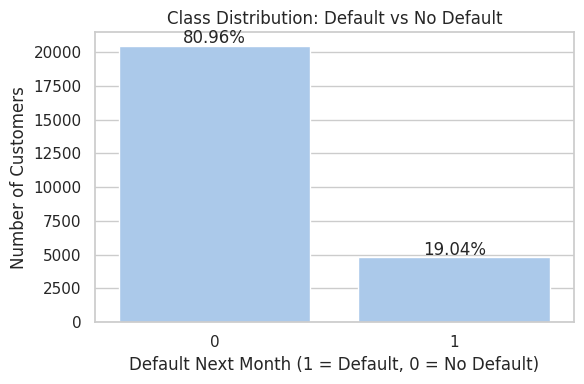

In [ ]:
# Set seaborn style
sns.set(style='whitegrid', palette='pastel')
plt.figure(figsize=(6, 4))

# Countplot
sns.countplot(x='next_month_default', data=df)
plt.title('Class Distribution: Default vs No Default')
plt.xlabel('Default Next Month (1 = Default, 0 = No Default)')
plt.ylabel('Number of Customers')

# Add percentages on bars
total = len(df)
for p in plt.gca().patches:
    count = p.get_height()
    percent = f'{100 * count / total:.2f}%'
    plt.text(p.get_x() + p.get_width() / 2, count + 200, percent, ha='center')

plt.tight_layout()
plt.show()



This is a class imbalance problem, meaning that our dataset has many more non-defaulters than defaulters. This impacts modeling in several ways:

Models tend to favor the majority class (0) by default, often predicting "No Default" for most customers to get high accuracy.

Accuracy becomes misleading — predicting all 0s gives ~81% accuracy, but fails to catch any actual defaults.

Recall on class 1 (defaults) becomes the key metric for risk assessment.



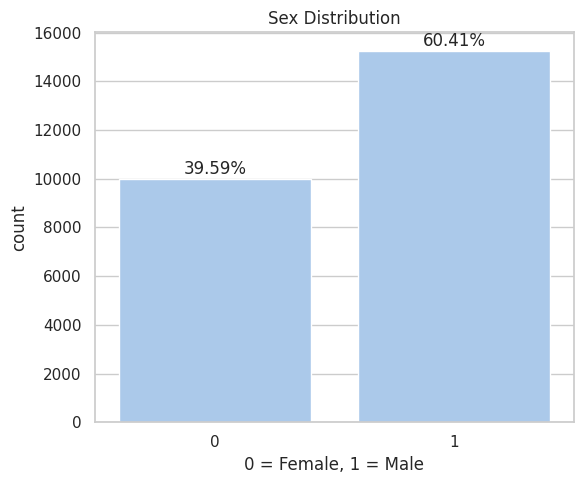

In [ ]:
plt.figure(figsize=(6,5))

# Sex distribution
sns.countplot(data=df, x='sex')
plt.title("Sex Distribution")
plt.xlabel("0 = Female, 1 = Male")

# Add percentages on bars
total = len(df)
for p in plt.gca().patches:
    count = p.get_height()
    percent = f'{100 * count / total:.2f}%'
    plt.text(p.get_x() + p.get_width() / 2, count + 200, percent, ha='center')

plt.tight_layout()
plt.show()



The chart shows that 60.41% of customers are male and 39.59% are female, indicating a gender imbalance in the dataset that may affect model fairness. No action is needed unless gender significantly impacts predictions or fairness is a concern which is not so in our case.

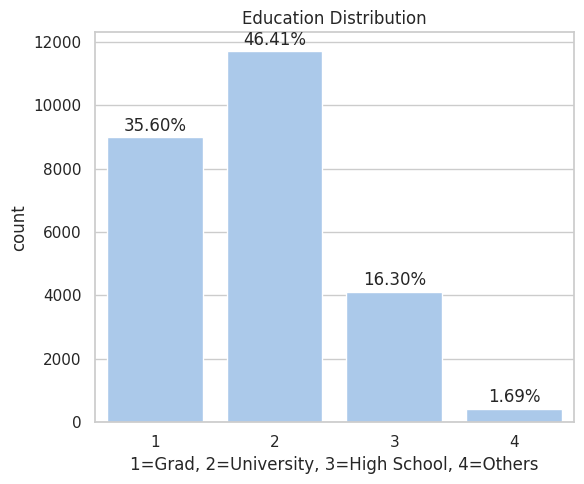

In [ ]:
plt.figure(figsize=(6,5))
# Education level
sns.countplot(data=df, x='education')
plt.title("Education Distribution")
plt.xlabel("1=Grad, 2=University, 3=High School, 4=Others")
# Add percentages on bars
total = len(df)
for p in plt.gca().patches:
    count = p.get_height()
    percent = f'{100 * count / total:.2f}%'
    plt.text(p.get_x() + p.get_width() / 2, count + 200, percent, ha='center')
plt.tight_layout()
plt.show()

Most customers are university-educated (46.41%), followed by graduates (35.60%) and high school-educated individuals (16.30%).

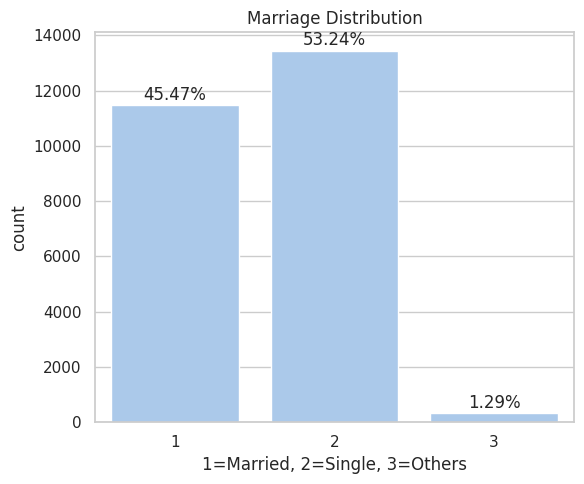

In [ ]:
plt.figure(figsize=(6,5))
# Marriage status
sns.countplot(data=df, x='marriage')
plt.title("Marriage Distribution")
plt.xlabel("1=Married, 2=Single, 3=Others")
# Add percentages on bars
total = len(df)
for p in plt.gca().patches:
    count = p.get_height()
    percent = f'{100 * count / total:.2f}%'
    plt.text(p.get_x() + p.get_width() / 2, count + 200, percent, ha='center')
plt.tight_layout()
plt.show()


The majority of customers are single (53.24%), followed by married individuals (45.47%), with a very small portion categorized as others (1.29%).

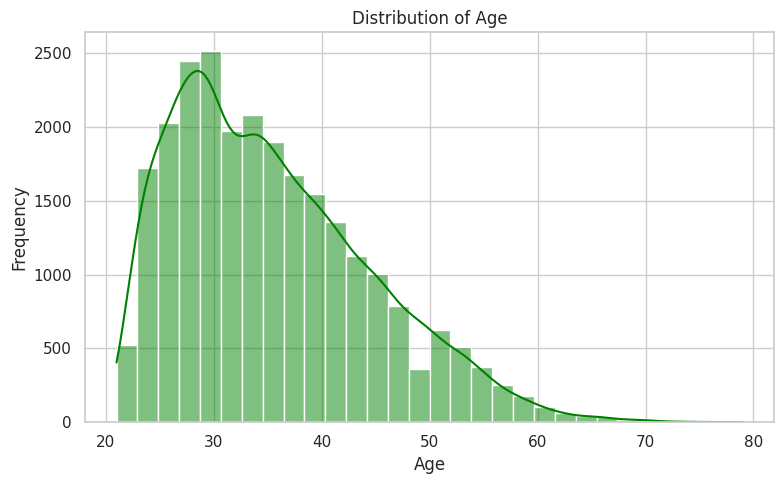

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, bins=30, color='green')

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

Most customers are in their late 20s to early 30s, with the age distribution skewed toward younger individuals.

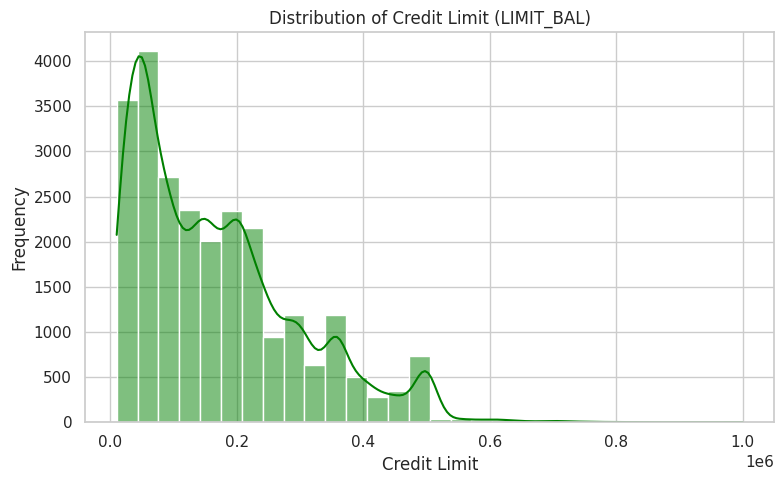

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['LIMIT_BAL'], kde=True, bins=30, color='green')

plt.title("Distribution of Credit Limit (LIMIT_BAL)")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


Most customers have a credit limit below 200,000, with fewer customers having significantly higher limits.

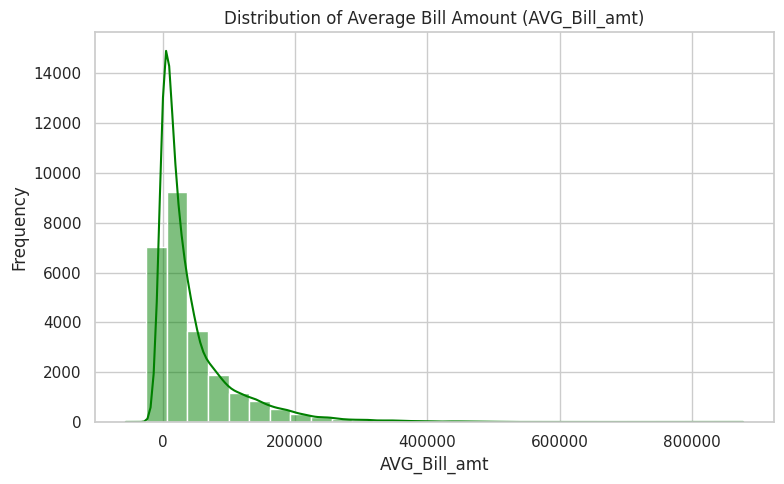

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['AVG_Bill_amt'], kde=True, bins=30, color='green')

plt.title("Distribution of Average Bill Amount (AVG_Bill_amt)")
plt.xlabel("AVG_Bill_amt")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

The distribution has a long tail to the right, meaning most customers have lower average bill amounts.

A small number of customers have significantly higher average bills, pulling the tail to the right.

This variable may benefit from a log transformation (np.log1p()) to normalize it.

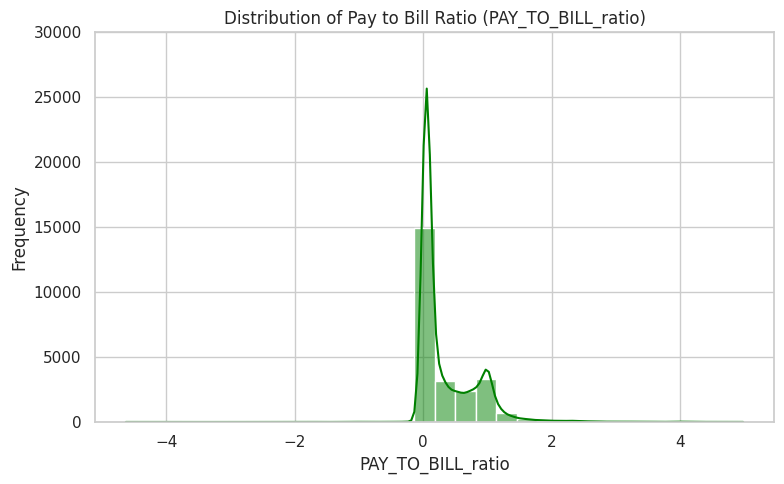

In [ ]:
plt.figure(figsize=(8, 5))

# Limit x values (e.g., between -5 and 5) to exclude extreme outliers
sns.histplot(df[(df['PAY_TO_BILL_ratio'] > -5) & (df['PAY_TO_BILL_ratio'] < 5)]['PAY_TO_BILL_ratio'],
             kde=True, bins=30, color='green')

plt.title("Distribution of Pay to Bill Ratio (PAY_TO_BILL_ratio)")
plt.xlabel("PAY_TO_BILL_ratio")
plt.ylabel("Frequency")

# Limit the y-axis for better visibility
plt.ylim(0, 30000)

plt.grid(True)
plt.tight_layout()
plt.show()



The Pay-to-Bill ratio is right-skewed and centered around zero, indicating most customers pay a small portion of their bills, with some outliers paying significantly more or less.

##Bivariate Analysis

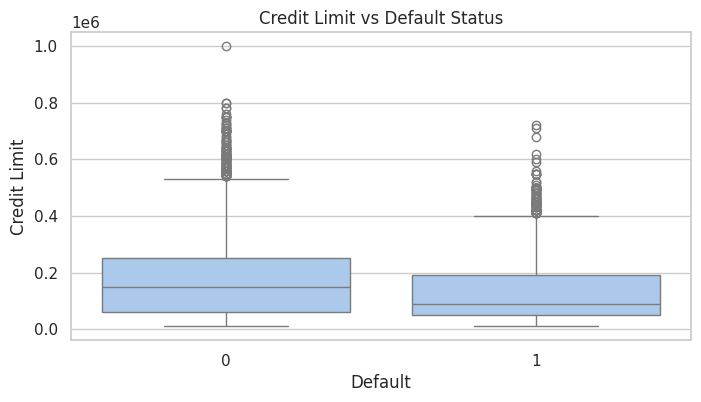

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default Status")
plt.xlabel("Default")
plt.ylabel("Credit Limit")
plt.show()


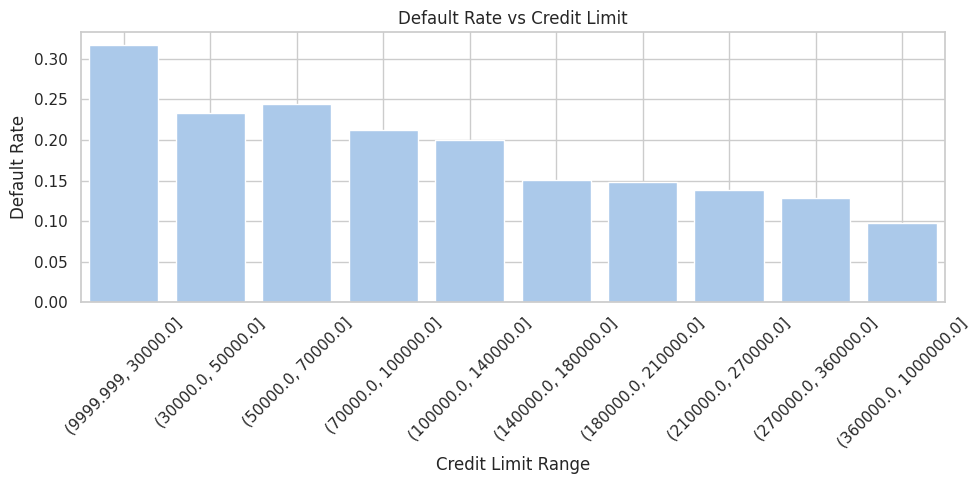

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bin credit limit into ranges
df['limit_bin'] = pd.qcut(df['LIMIT_BAL'], q=10)

# Plot default rate per bin
plt.figure(figsize=(10, 5))
sns.barplot(x='limit_bin', y='next_month_default', data=df, estimator=lambda x: x.mean(), errorbar=None)
plt.xticks(rotation=45)
plt.title('Default Rate vs Credit Limit')
plt.xlabel('Credit Limit Range')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.grid(True)
plt.show()


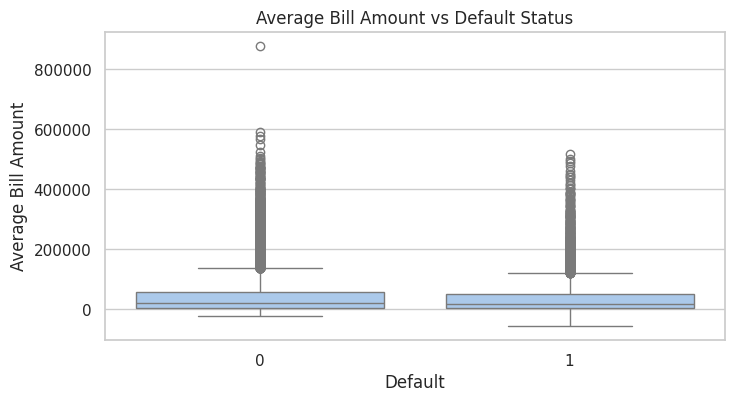

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='AVG_Bill_amt', data=df)
plt.title("Average Bill Amount vs Default Status")
plt.xlabel("Default")
plt.ylabel("Average Bill Amount")
plt.show()


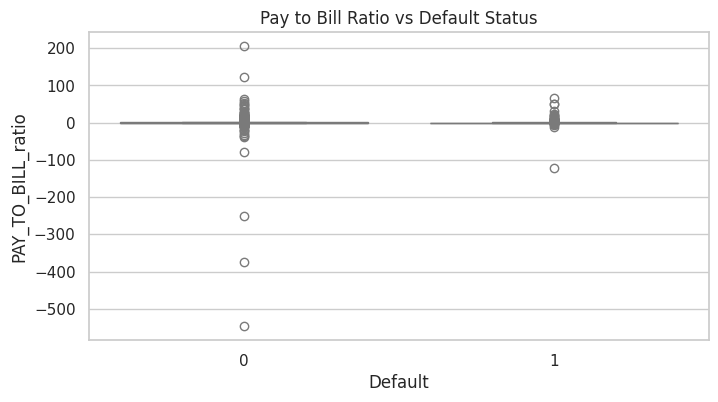

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='PAY_TO_BILL_ratio', data=df)
plt.title("Pay to Bill Ratio vs Default Status")
plt.xlabel("Default")
plt.ylabel("PAY_TO_BILL_ratio")
plt.show()


In [ ]:
# List of selected columns
selected_columns = [
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
    'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'next_month_default'
]
filtered_df = df[
    ((df['AVG_Bill_amt'] < 0))
][selected_columns]

# Display filtered DataFrame

filtered_df  # or just `filtered_df` to see all



,Bill_amt1,Bill_amt2,Bill_amt3,Bill_amt4,Bill_amt5,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
83,3073.53,0.00,0.00,0.00,0.00,0.00,9203.06,0.00,0.20,0.08,0.00,8000.13,-8867.33,-0.32,0
167,0.00,0.00,0.00,0.00,760.07,760.37,0.07,0.00,0.00,1519.99,0.22,0.00,-158.33,-1.60,0
185,1213.02,791.35,2664.44,781.79,1729.29,0.00,1031.95,2663.16,782.86,1730.15,0.06,70803.11,-7377.33,-1.74,1
368,0.00,0.00,0.00,0.00,0.00,0.00,0.23,0.00,0.13,0.00,0.03,999.85,-1000.00,-0.17,1
528,0.00,0.00,0.00,0.00,5887.45,3881.44,0.18,0.00,0.33,16824.83,0.00,1823.01,-2596.83,-1.20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24900,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.17,-18.00,0.00,0
24940,0.00,389.96,0.00,780.75,0.29,0.00,2999.91,0.01,780.04,0.00,0.00,0.24,-240.00,-2.62,0
24979,1766.83,0.00,0.00,0.00,1697.69,4347.66,0.00,0.00,2000.27,3999.89,3000.02,4999.71,-253.00,-9.22,0
25104,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.44,0.08,0.00,0.07,0.06,-933.33,0.00,0


In [ ]:
# Step 1: Calculate new AVG_Bill_amt
df['AVG_Bill_amt'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].mean(axis=1)

# Step 2: Calculate total bill and payment across 6 months
df['total_bill_amt'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].sum(axis=1)
df['total_pay_amt'] = df[[f'pay_amt{i}' for i in range(1, 7)]].sum(axis=1)

# Step 3: Calculate PAY_TO_BILL_ratio (handling divide-by-zero safely)
df['PAY_TO_BILL_ratio'] = df['total_pay_amt'] / df['total_bill_amt'].replace(0, np.nan)

# Step 4: Optional — fill NaNs from division by zero with 0 or another placeholder
df['PAY_TO_BILL_ratio'] = df['PAY_TO_BILL_ratio'].fillna(0)




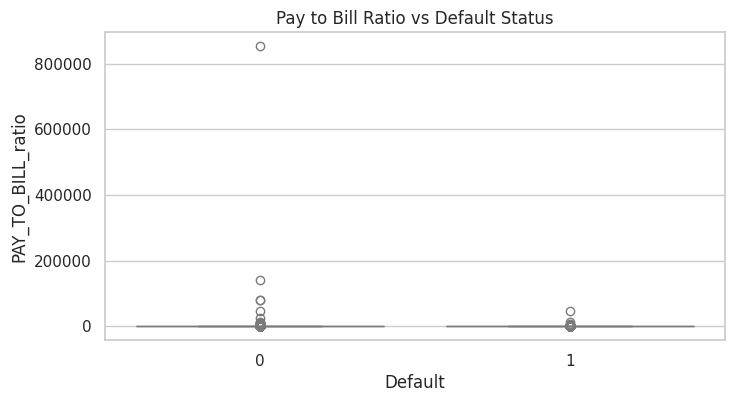

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='PAY_TO_BILL_ratio', data=df)
plt.title("Pay to Bill Ratio vs Default Status")
plt.xlabel("Default")
plt.ylabel("PAY_TO_BILL_ratio")
plt.show()

In [ ]:
# List of selected columns
selected_columns = [
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
    'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'next_month_default'
]
filtered_df = df[
    ((df['total_pay_amt'] > 10000) & (df['total_bill_amt']<10))
][selected_columns]

# Display filtered DataFrame

filtered_df  # or just `filtered_df` to see all

,Bill_amt1,Bill_amt2,Bill_amt3,Bill_amt4,Bill_amt5,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
304,0.83,0.00,0.50,0.41,0.00,0.52,0.03,0.00,0.00,0.00,0.00,17000.23,0.376667,7522.238938,0
1105,0.35,0.10,1.09,0.26,0.40,0.00,0.12,99999.80,0.00,0.17,0.27,0.00,0.366667,45454.709091,0
5538,0.99,0.27,0.88,0.00,0.00,0.44,0.00,0.00,0.00,10000.18,0.23,0.02,0.430000,3876.135659,0
6959,0.00,0.00,0.00,0.19,0.00,0.00,0.00,0.25,0.00,0.26,161999.93,0.08,0.031667,852634.315789,0
13090,0.01,0.00,0.00,0.55,0.22,0.28,0.08,0.16,0.00,0.30,0.03,84215.92,0.176667,79449.518868,0
13661,0.00,0.12,0.42,1.31,0.00,0.00,0.00,0.00,0.00,0.00,0.11,85929.06,0.308333,46448.200000,1
18570,0.88,0.17,0.38,0.58,0.13,0.03,0.22,0.02,0.00,0.01,0.00,19408.83,0.361667,8944.276498,0
19303,0.16,0.00,0.04,0.00,0.00,0.00,0.19,0.00,0.00,0.00,0.02,28027.21,0.033333,140137.100000,0
19422,0.54,0.42,0.00,0.10,0.34,0.04,0.10,0.14,0.08,0.02,0.00,35909.88,0.240000,24937.652778,0
20402,0.88,0.17,0.38,0.58,0.13,0.03,0.22,0.02,0.00,0.01,0.00,19408.83,0.361667,8944.276498,0


In [ ]:
# Drop rows where total_pay_amt > 10000 and total_bill_amt < 10
df = df[~((df['total_pay_amt'] > 10000) & (df['total_bill_amt'] < 10))].copy()


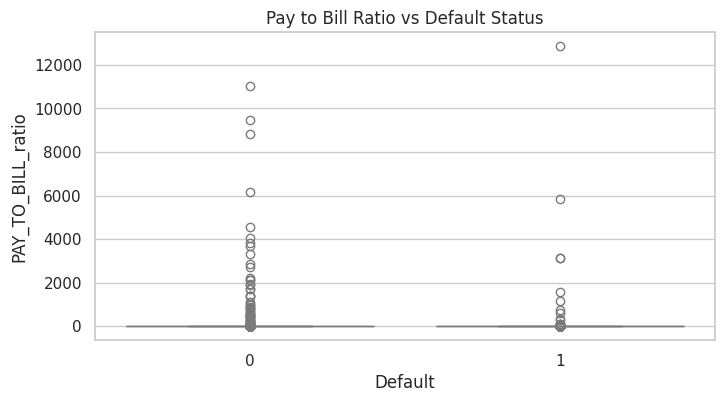

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='PAY_TO_BILL_ratio', data=df)
plt.title("Pay to Bill Ratio vs Default Status")
plt.xlabel("Default")
plt.ylabel("PAY_TO_BILL_ratio")
plt.show()

In [ ]:
# List of selected columns
selected_columns = [
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
    'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'next_month_default'
]
filtered_df = df[
    ((df['PAY_TO_BILL_ratio'] > 5000))
][selected_columns]

# Display filtered DataFrame

filtered_df  # or just `filtered_df` to see all

,Bill_amt1,Bill_amt2,Bill_amt3,Bill_amt4,Bill_amt5,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
12225,0.00,0.00,0.43,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3788.96,0.071667,8811.534884,0
17175,0.09,0.00,0.39,0.0,0.33,0.00,0.02,0.00,0.04,0.04,0.02,4999.94,0.135000,6172.913580,0
17611,0.00,0.05,0.00,0.0,0.50,0.00,0.04,0.42,0.00,0.05,0.00,3220.05,0.091667,5855.563636,1
21446,0.00,0.91,0.00,0.0,0.00,0.00,0.42,0.00,0.00,0.06,0.23,8618.27,0.151667,9471.406593,0
21940,0.00,0.00,0.00,0.0,0.00,0.21,0.10,899.98,1799.88,0.01,0.00,0.32,0.035000,12858.523810,1
24523,0.00,0.00,0.00,0.0,0.23,0.08,0.25,0.16,0.05,0.00,0.09,3422.03,0.051667,11040.580645,0


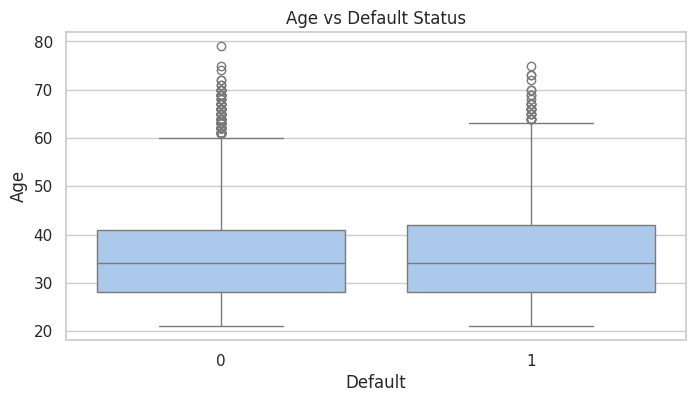

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='age', data=df)
plt.title("Age vs Default Status")
plt.xlabel("Default")
plt.ylabel("Age")
plt.show()


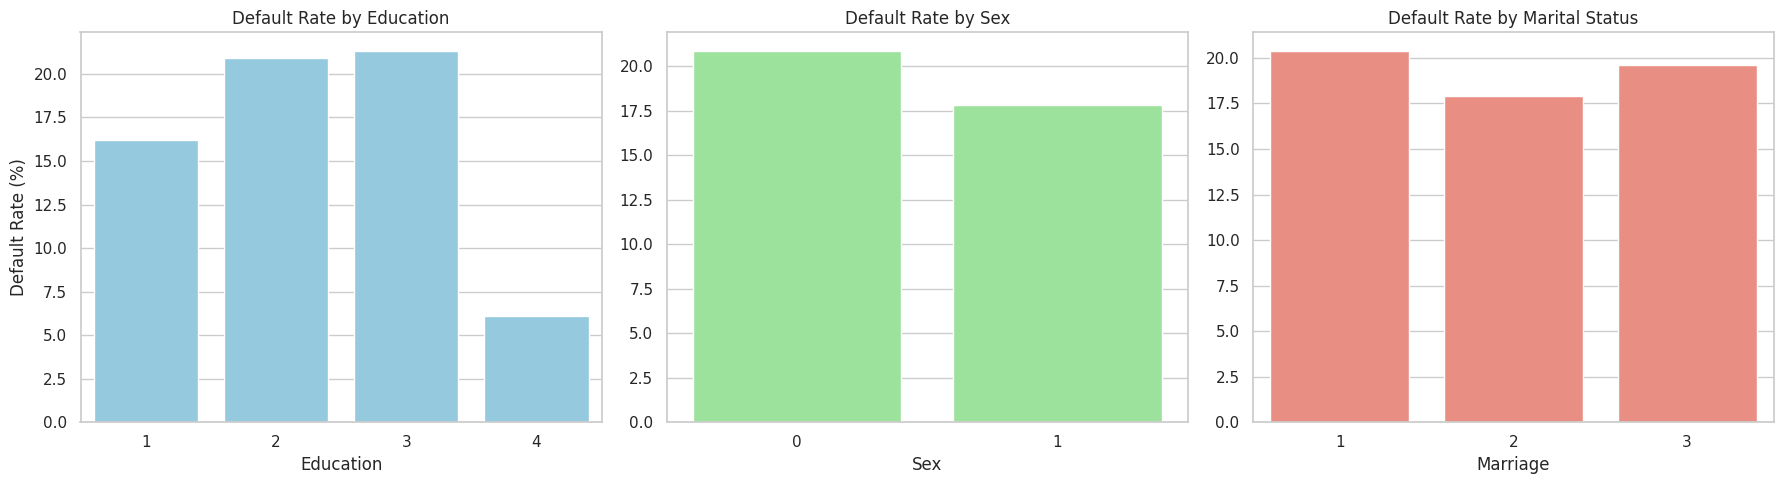

In [ ]:
# Set up plot style
sns.set(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------
# 1. Default Rate by Education
edu_default = df.groupby('education')['next_month_default'].mean().reset_index()
edu_default['default_percent'] = edu_default['next_month_default'] * 100
sns.barplot(data=edu_default, x='education', y='default_percent', color='skyblue', ax=axes[0])
axes[0].set_title('Default Rate by Education')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Education')

# -------------------------------
# 2. Default Rate by Sex
sex_default = df.groupby('sex')['next_month_default'].mean().reset_index()
sex_default['default_percent'] = sex_default['next_month_default'] * 100
sns.barplot(data=sex_default, x='sex', y='default_percent', color='lightgreen', ax=axes[1])
axes[1].set_title('Default Rate by Sex')
axes[1].set_ylabel('')
axes[1].set_xlabel('Sex')

# -------------------------------
# 3. Default Rate by Marriage
marriage_default = df.groupby('marriage')['next_month_default'].mean().reset_index()
marriage_default['default_percent'] = marriage_default['next_month_default'] * 100
sns.barplot(data=marriage_default, x='marriage', y='default_percent', color='salmon', ax=axes[2])
axes[2].set_title('Default Rate by Marital Status')
axes[2].set_ylabel('')
axes[2].set_xlabel('Marriage')

# Adjust layout
plt.tight_layout()
plt.show()



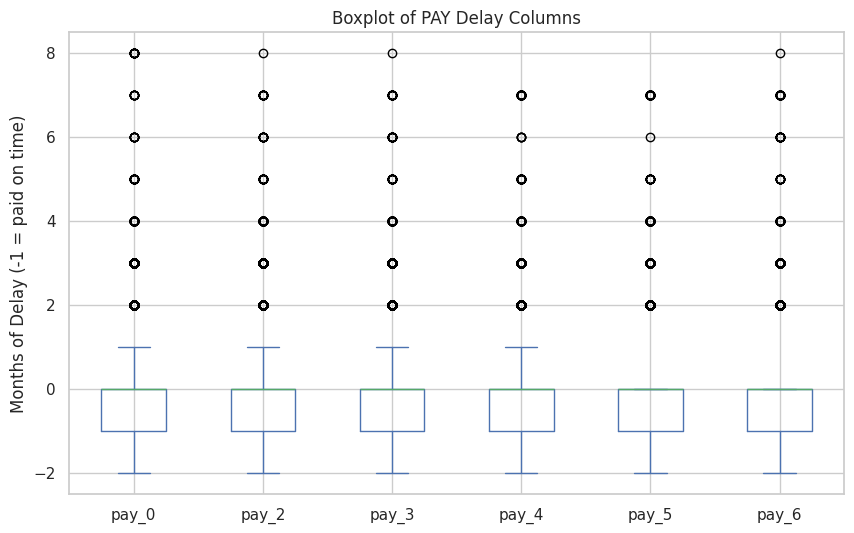

In [ ]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df[pay_cols].plot(kind='box', figsize=(10, 6), title='Boxplot of PAY Delay Columns')
plt.ylabel("Months of Delay (-1 = paid on time)")
plt.show()

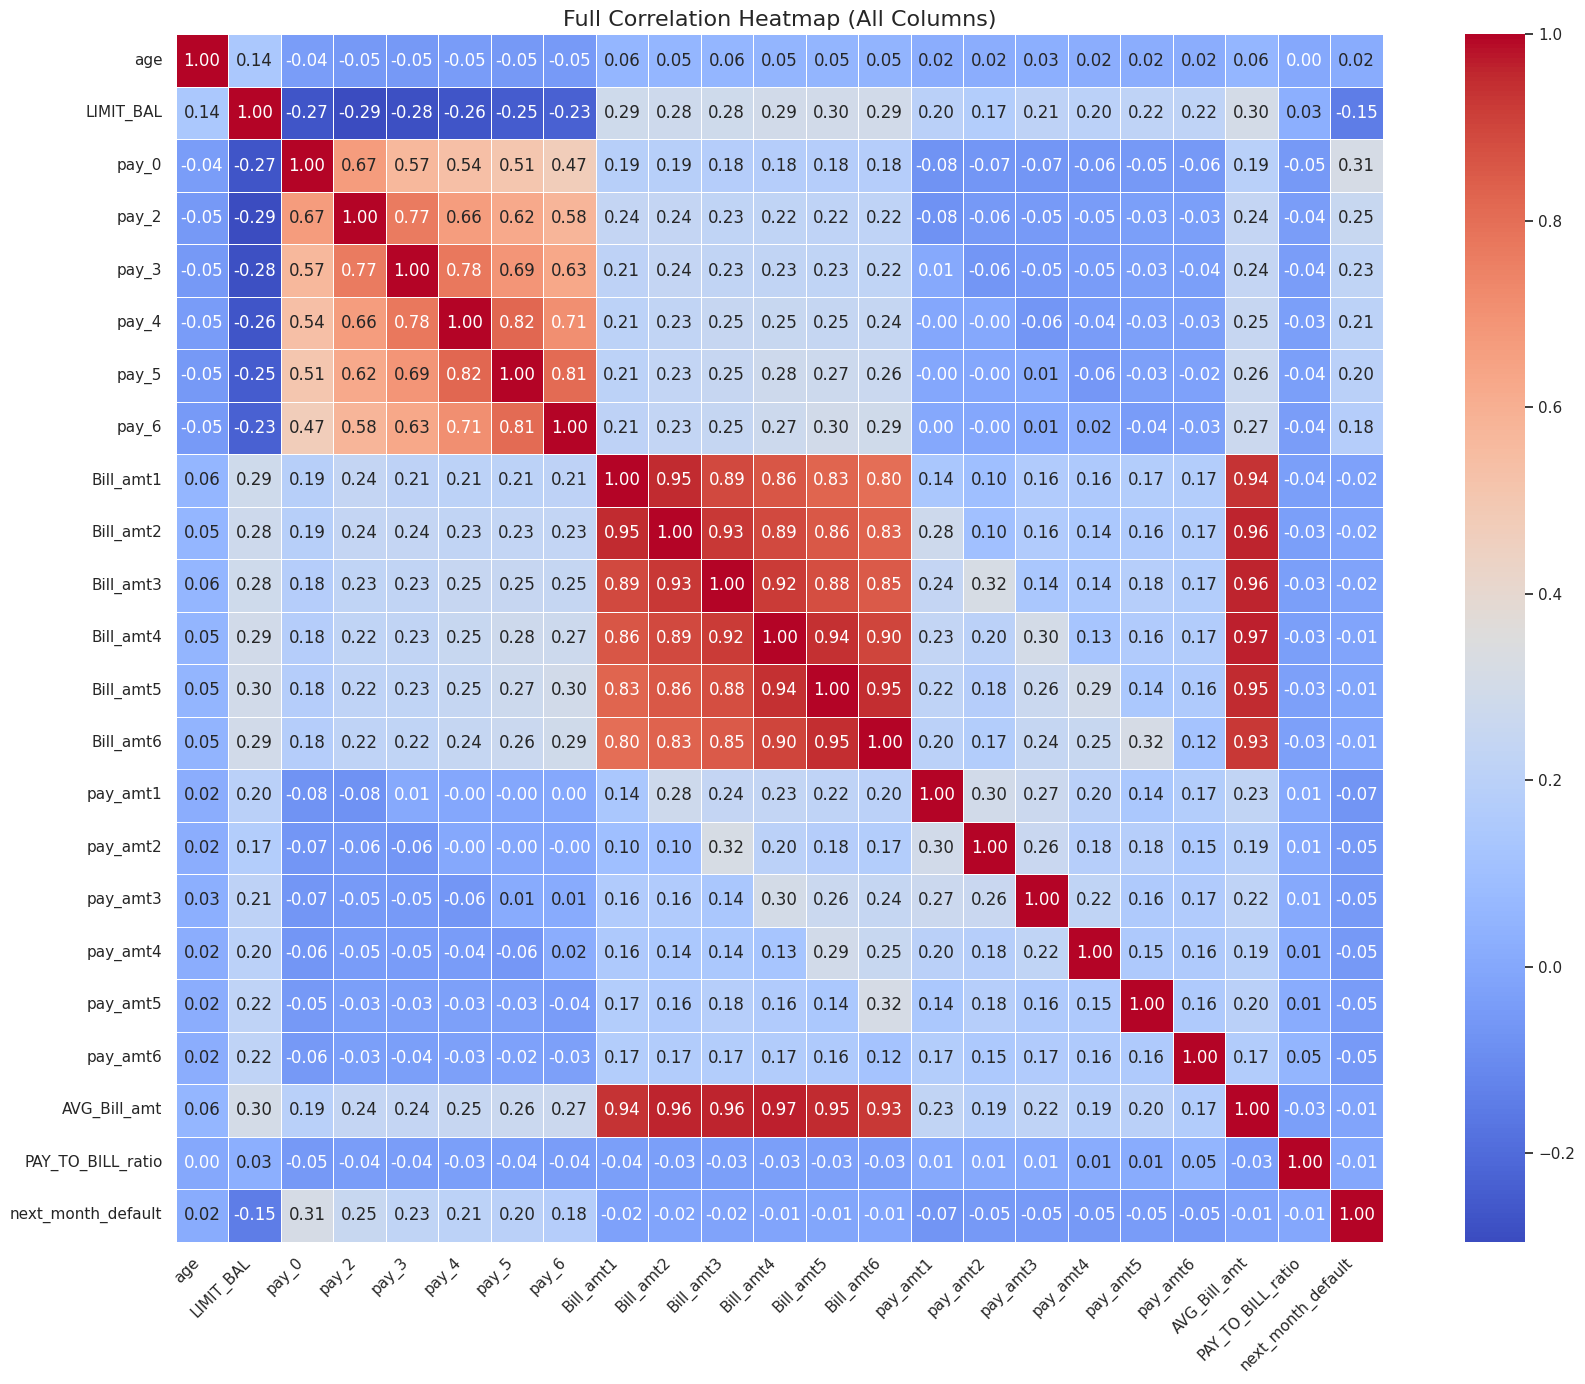

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Logical order of columns
cols_ordered = [ 'age', 'LIMIT_BAL',
    'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
    'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'next_month_default'
]

# Compute correlation matrix
corr_matrix = df[cols_ordered].corr(numeric_only=True)

# Plot full heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Full Correlation Heatmap (All Columns)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()







#Feature Engineering

In [ ]:
# Get columns for repayment status
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

def max_delinquency_streak(row):
    streak = 0
    max_streak = 0
    for val in row:
        if val >= 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

df['max_delinquency_streak'] = df[pay_cols].apply(max_delinquency_streak, axis=1)


<ipython-input-49-1506645459>:20: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  plt.legend(handles=handles, labels=["No", "Yes"], title="Default Next Month")
<ipython-input-49-1506645459>:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=["No", "Yes"], title="Default Next Month")


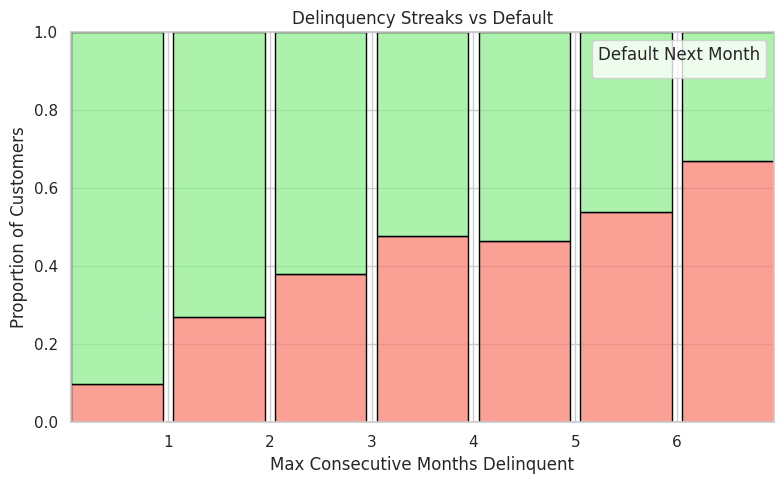

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='max_delinquency_streak',
    hue='next_month_default',
    bins=range(0, 8),
    multiple='fill',
    shrink=0.9,
    palette={0: "lightgreen", 1: "salmon"},  # 0 = No, 1 = Yes
    edgecolor='black'
)

plt.title("Delinquency Streaks vs Default")
plt.xlabel("Max Consecutive Months Delinquent")
plt.ylabel("Proportion of Customers")
plt.grid(True)

# Update legend manually to match color/hue mapping
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["No", "Yes"], title="Default Next Month")

plt.tight_layout()
plt.show()



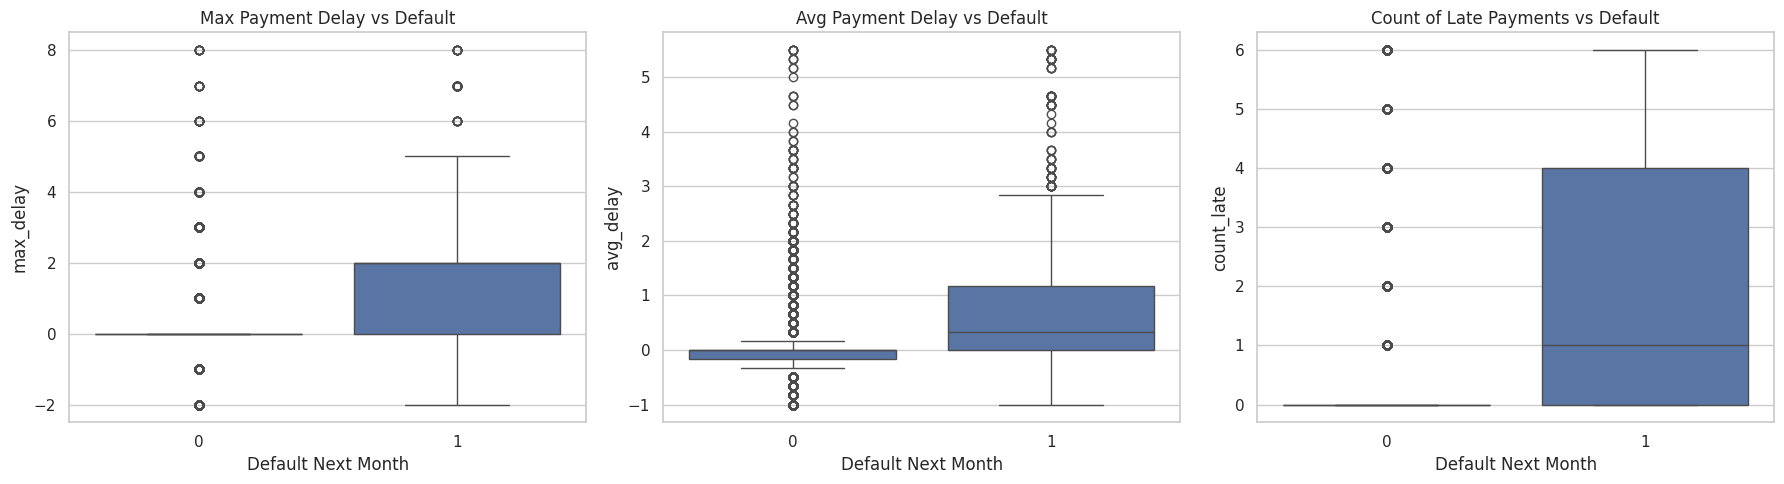

In [ ]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

df['max_delay'] = df[pay_cols].max(axis=1)
df['avg_delay'] = df[pay_cols].replace(-2, 0).mean(axis=1)
df['count_late'] = df[pay_cols].apply(lambda row: sum(row > 0), axis=1)

# Visualize
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='next_month_default', y='max_delay', data=df, ax=axs[0])
sns.boxplot(x='next_month_default', y='avg_delay', data=df, ax=axs[1])
sns.boxplot(x='next_month_default', y='count_late', data=df, ax=axs[2])

axs[0].set_title('Max Payment Delay vs Default')
axs[1].set_title('Avg Payment Delay vs Default')
axs[2].set_title('Count of Late Payments vs Default')
for ax in axs: ax.set_xlabel("Default Next Month")
plt.tight_layout()
plt.show()



In [ ]:
# Define PAY status columns
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

# Repayment consistency: proportion of months paid on time or early
df['repayment_consistency'] = df[pay_cols].apply(lambda row: sum(row <= 0) / len(row), axis=1)



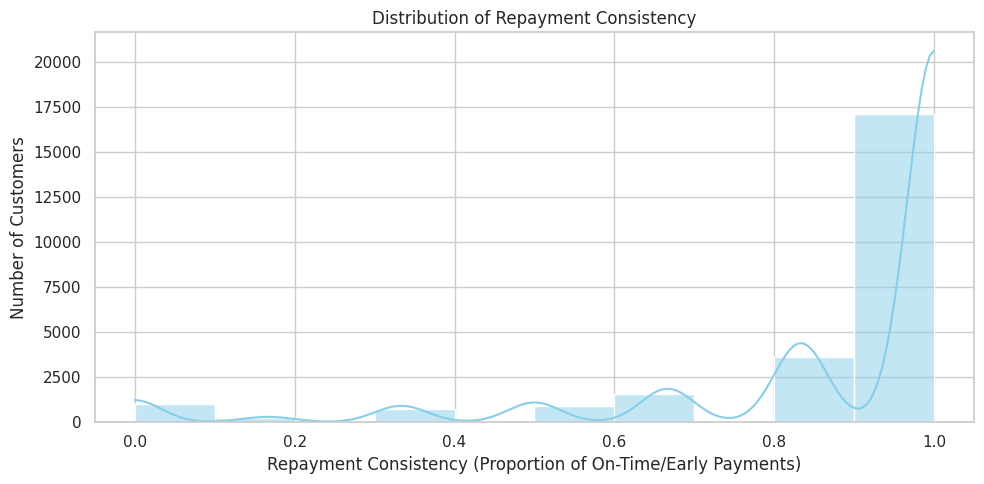

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['repayment_consistency'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Repayment Consistency")
plt.xlabel("Repayment Consistency (Proportion of On-Time/Early Payments)")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-44-790051700>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df.groupby('consistency_bin')['next_month_default'].mean().reset_index()
<ipython-input-44-790051700>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x='consistency_bin', y='next_month_default', palette='viridis')


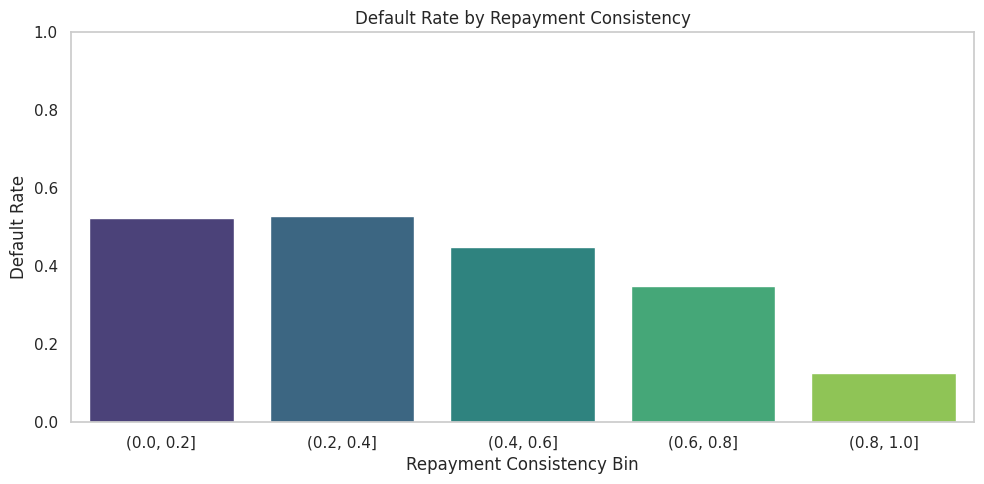

In [ ]:
# Bin the consistency for grouped analysis
df['consistency_bin'] = pd.cut(df['repayment_consistency'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Calculate default rate per bin
default_rate = df.groupby('consistency_bin')['next_month_default'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=default_rate, x='consistency_bin', y='next_month_default', palette='viridis')
plt.title("Default Rate by Repayment Consistency")
plt.xlabel("Repayment Consistency Bin")
plt.ylabel("Default Rate")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


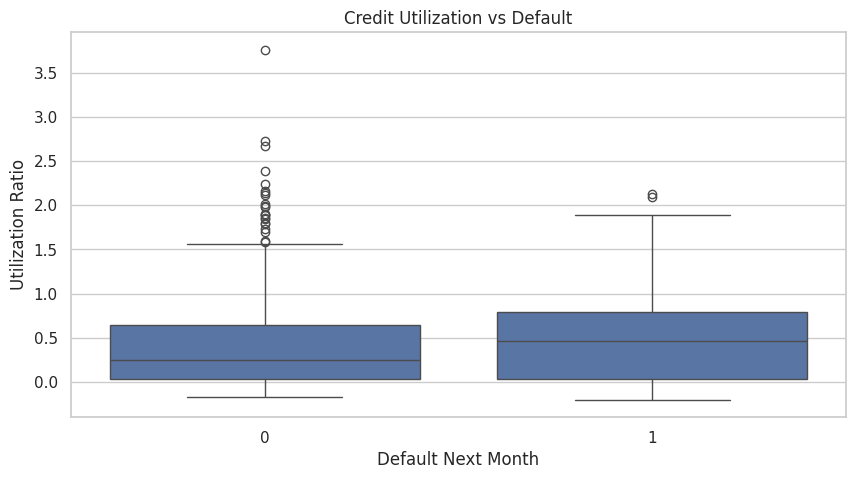

In [ ]:
df['utilization_ratio'] = df['AVG_Bill_amt'] / df['LIMIT_BAL']

plt.figure(figsize=(10, 5))
sns.boxplot(x='next_month_default', y='utilization_ratio', data=df)
plt.title("Credit Utilization vs Default")
plt.xlabel("Default Next Month")
plt.ylabel("Utilization Ratio")
plt.show()


In [ ]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

# Replace special values if needed (-2 for no credit use, etc.)
df[pay_cols] = df[pay_cols].replace(-2, 0)

# Calculate average change in payment status across months
df['delinquency_trend'] = df[pay_cols].diff(axis=1).mean(axis=1)


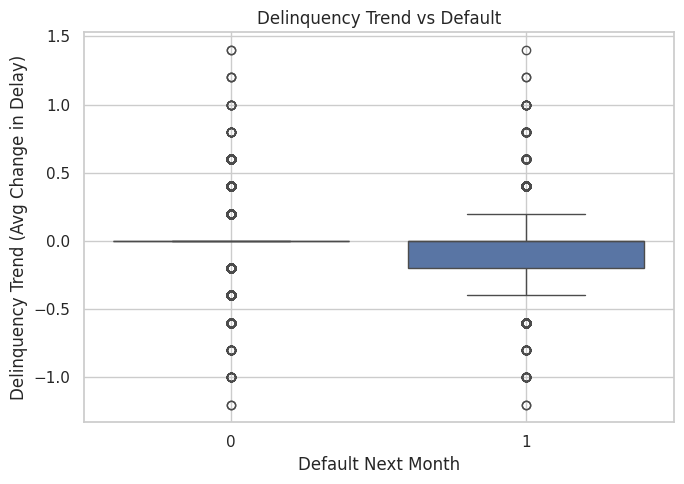

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='next_month_default', y='delinquency_trend')
plt.title('Delinquency Trend vs Default')
plt.xlabel('Default Next Month')
plt.ylabel('Delinquency Trend (Avg Change in Delay)')
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:
# Calculate overpayment based on proper alignment
overpayment_flags = [
    df[f'pay_amt{i+1}'] > df[f'Bill_amt{i}']
    for i in range(1, 6)  # 1 to 5 because pay_amt6 relates to Bill_amt5
]
df['overpayment_count'] = sum(overpayment_flags)


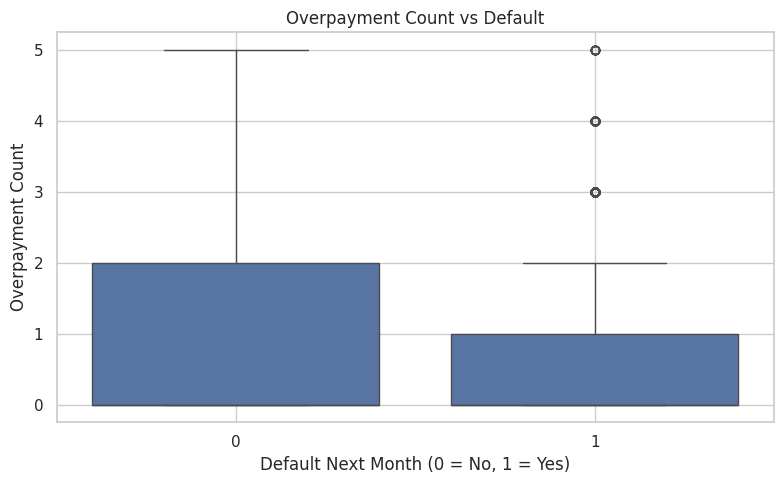

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x='next_month_default', y='overpayment_count', data=df)
plt.title("Overpayment Count vs Default")
plt.xlabel("Default Next Month (0 = No, 1 = Yes)")
plt.ylabel("Overpayment Count")
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-58-3706553743>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


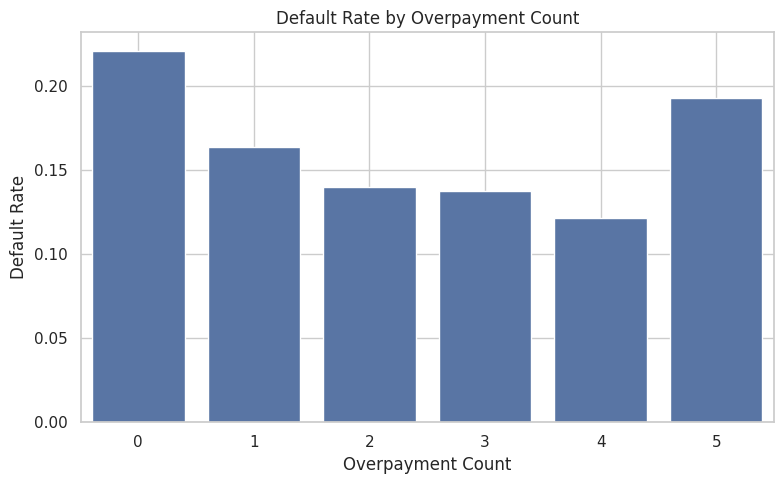

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='overpayment_count',
    y='next_month_default',
    data=df,
    estimator=lambda x: sum(x)/len(x),  # default rate
    ci=None
)
plt.title("Default Rate by Overpayment Count")
plt.xlabel("Overpayment Count")
plt.ylabel("Default Rate")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df['bill_amt_std'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].std(axis=1)
df['pay_amt_std'] = df[[f'pay_amt{i}' for i in range(1, 7)]].std(axis=1)


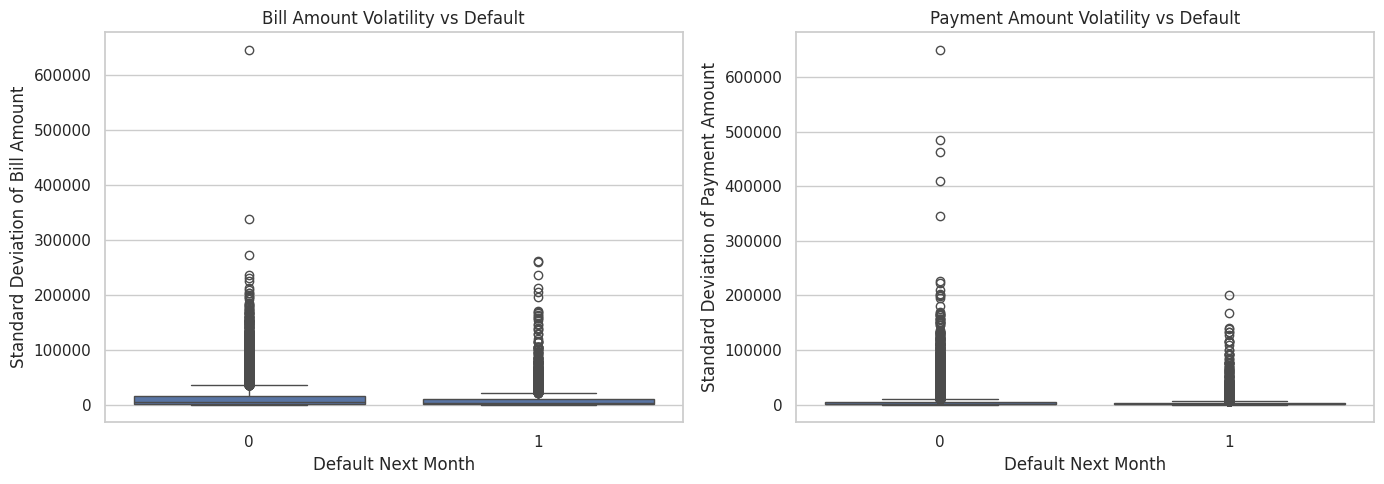

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Bill volatility vs default
plt.subplot(1, 2, 1)
sns.boxplot(x='next_month_default', y='bill_amt_std', data=df)
plt.title('Bill Amount Volatility vs Default')
plt.xlabel('Default Next Month')
plt.ylabel('Standard Deviation of Bill Amount')

# Payment volatility vs default
plt.subplot(1, 2, 2)
sns.boxplot(x='next_month_default', y='pay_amt_std', data=df)
plt.title('Payment Amount Volatility vs Default')
plt.xlabel('Default Next Month')
plt.ylabel('Standard Deviation of Payment Amount')

plt.tight_layout()
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25234 entries, 0 to 25246
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Customer_ID             25234 non-null  int64   
 1   marriage                25234 non-null  int64   
 2   sex                     25234 non-null  int64   
 3   education               25234 non-null  int64   
 4   LIMIT_BAL               25234 non-null  int64   
 5   age                     25234 non-null  float64 
 6   pay_0                   25234 non-null  int64   
 7   pay_2                   25234 non-null  int64   
 8   pay_3                   25234 non-null  int64   
 9   pay_4                   25234 non-null  int64   
 10  pay_5                   25234 non-null  int64   
 11  pay_6                   25234 non-null  int64   
 12  Bill_amt1               25234 non-null  float64 
 13  Bill_amt2               25234 non-null  float64 
 14  Bill_amt3               252

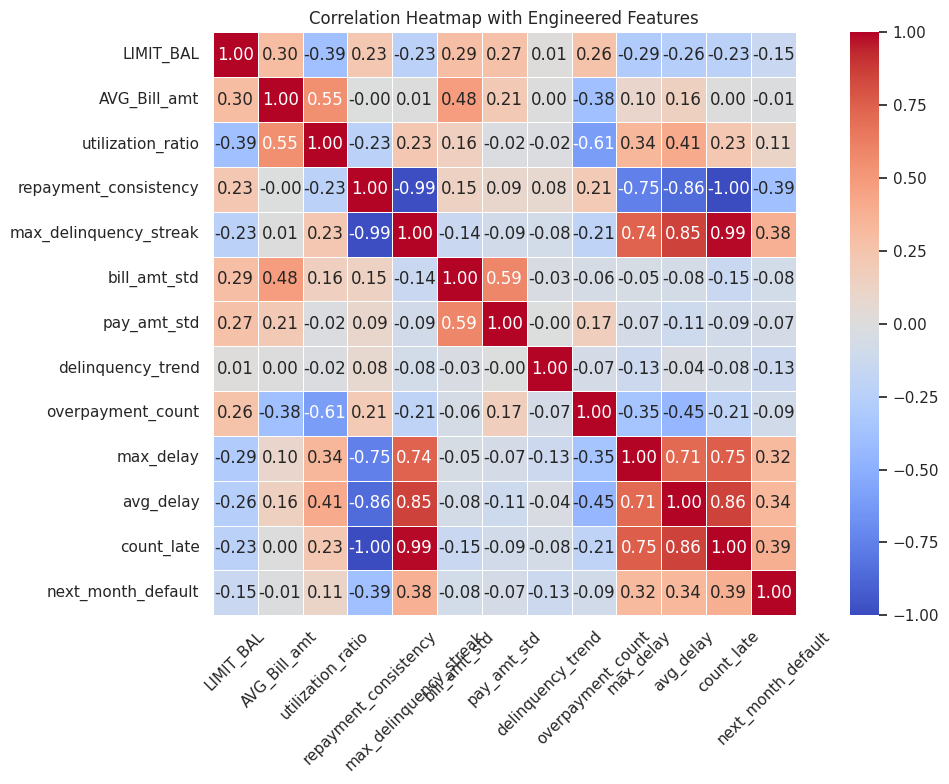

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numeric features for correlation
correlation_features = [
    'LIMIT_BAL', 'AVG_Bill_amt', 'age'
    'PAY_TO_BILL_ratio', 'utilization_ratio', 'repayment_consistency', 'max_delinquency_streak', 'bill_amt_std','pay_amt_std','delinquency_trend', 'overpayment_count',
    'max_delay', 'avg_delay', 'count_late',
    'next_month_default'  # Include target variable
]

# Optional: only include features that exist in df
correlation_features = [col for col in correlation_features if col in df.columns]

# Compute correlation matrix
corr_matrix = df[correlation_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Heatmap with Engineered Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# List of numeric columns (customize based on your dataset)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate skewness
skew_values = df[numeric_cols].skew().sort_values(ascending=False)

# Show highly skewed columns (e.g., skewness > 1 or < -1)
print("Highly skewed columns:")
print(skew_values[abs(skew_values) > 1])


Highly skewed columns:
PAY_TO_BILL_ratio         52.471144
pay_amt2                  31.194057
pay_amt3                  17.918453
total_pay_amt             15.466679
pay_amt1                  15.263164
pay_amt4                  13.190200
pay_amt5                  11.167303
pay_amt6                  10.738511
pay_amt_std               10.417095
bill_amt_std               4.995426
Bill_amt3                  3.151527
Bill_amt5                  2.903892
Bill_amt6                  2.899877
Bill_amt4                  2.833509
AVG_Bill_amt               2.739863
total_bill_amt             2.739863
Bill_amt2                  2.706423
Bill_amt1                  2.665068
max_delinquency_streak     2.373043
pay_5                      2.372444
pay_6                      2.248499
count_late                 2.223089
pay_4                      2.188846
avg_delay                  2.005035
pay_3                      1.753356
pay_2                      1.665807
pay_0                      1.605423
next_

In [ ]:
# Define PAY column names in lowercase
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']



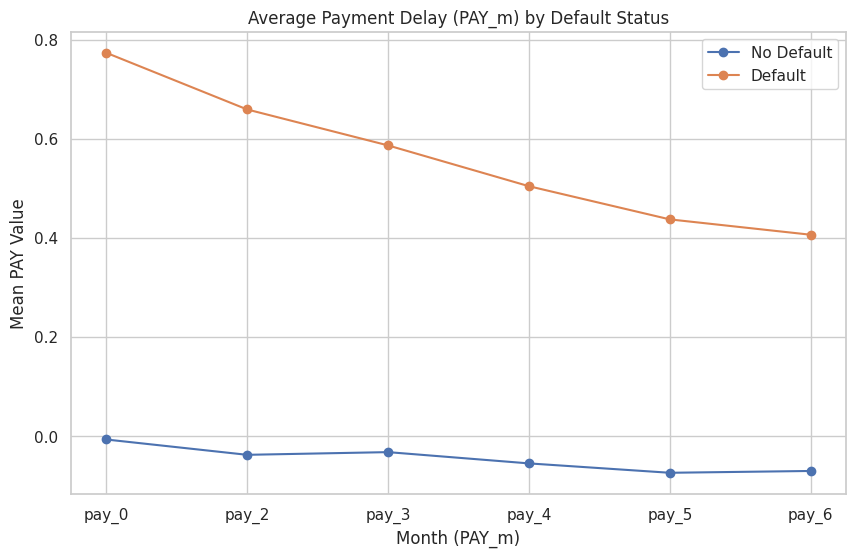

In [ ]:
# Average delay per month grouped by default status
grouped_pay = df.groupby('next_month_default')[pay_cols].mean().T

# Plot line chart of average delay trends
grouped_pay.plot(kind='line', marker='o')
plt.title("Average Payment Delay (PAY_m) by Default Status")
plt.ylabel("Mean PAY Value")
plt.xlabel("Month (PAY_m)")
plt.legend(['No Default', 'Default'])
plt.grid(True)
plt.show()


<ipython-input-63-2876753313>:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='pay_bin', y='next_month_default', data=df, estimator=lambda x: x.mean(), ci=None)


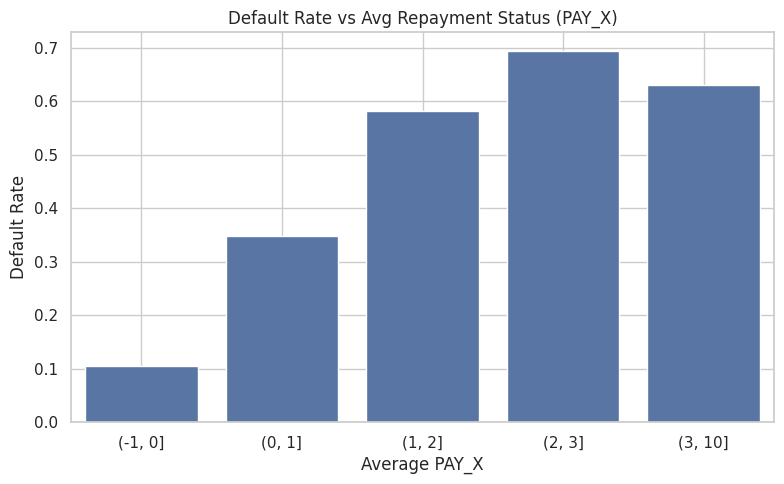

In [ ]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df['avg_PAY_X'] = df[pay_cols].replace(-2, 0).mean(axis=1)

# Bin average PAY_X
df['pay_bin'] = pd.cut(df['avg_PAY_X'], bins=[-1, 0, 1, 2, 3, 10])

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='pay_bin', y='next_month_default', data=df, estimator=lambda x: x.mean(), ci=None)
plt.title('Default Rate vs Avg Repayment Status (PAY_X)')
plt.xlabel('Average PAY_X')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.grid(True)
plt.show()


<ipython-input-65-2310308995>:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pay_status_long = df[pay_cols].applymap(categorize_payment)


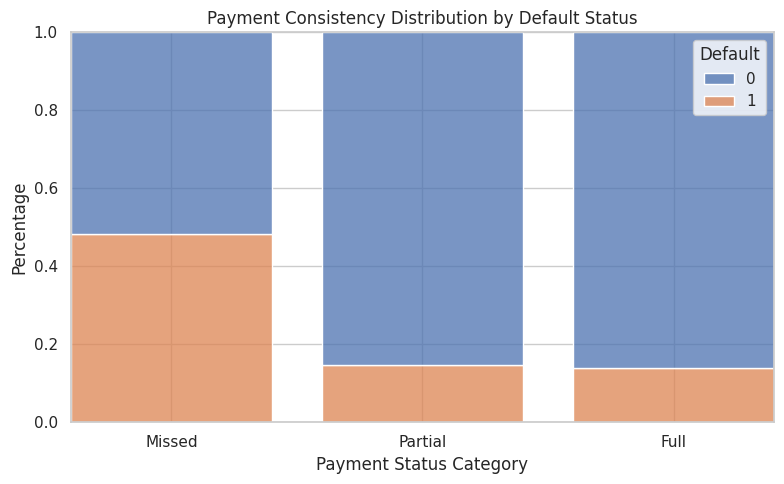

In [ ]:
def categorize_payment(val):
    if val == -1:
        return 'Full'
    elif val == 0:
        return 'Partial'
    elif val > 0:
        return 'Missed'
    else:
        return 'Other'

# Flatten repayment status into long format
pay_status_long = df[pay_cols].applymap(categorize_payment)
pay_status_long['Customer'] = df['Customer_ID']
pay_status_long['Default'] = df['next_month_default']
pay_melted = pd.melt(pay_status_long, id_vars=['Customer', 'Default'], value_name='PaymentStatus')

# Countplot of payment consistency
plt.figure(figsize=(8, 5))
sns.histplot(data=pay_melted, x='PaymentStatus', hue='Default', multiple='fill', stat='percent', shrink=0.8)
plt.title('Payment Consistency Distribution by Default Status')
plt.xlabel('Payment Status Category')
plt.ylabel('Percentage')
plt.tight_layout()
plt.grid(True)
plt.show()


In [ ]:
df_copied=df.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25247 entries, 0 to 25246
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   marriage                25247 non-null  int64  
 1   sex                     25247 non-null  int64  
 2   education               25247 non-null  int64  
 3   LIMIT_BAL               25247 non-null  int64  
 4   age                     25247 non-null  float64
 5   pay_0                   25247 non-null  int64  
 6   pay_2                   25247 non-null  int64  
 7   pay_3                   25247 non-null  int64  
 8   pay_4                   25247 non-null  int64  
 9   pay_5                   25247 non-null  int64  
 10  pay_6                   25247 non-null  int64  
 11  AVG_Bill_amt            25247 non-null  float64
 12  PAY_TO_BILL_ratio       25247 non-null  float64
 13  next_month_default      25247 non-null  int64  
 14  max_delinquency_streak  25247 non-null

In [ ]:
# Drop columns not needed for modeling
cols_to_drop = [
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
]

df = df.drop(columns=cols_to_drop)
df.head()


,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,max_delinquency_streak,max_delay,avg_delay,count_late,repayment_consistency,utilization_ratio,delinquency_trend,overpayment_count,bill_amt_std,pay_amt_std
0,5017,2,0,2,60000,25.0,2,2,2,0,...,3,2,1.000000,3,0.5,0.691858,-0.4,0,19585.483475,714.956931
1,5018,2,1,1,290000,24.0,0,0,0,0,...,0,0,-0.166667,0,1.0,0.008740,0.0,1,4360.101233,1129.473118
2,5019,1,0,2,180000,63.0,0,0,0,0,...,0,0,0.000000,0,1.0,0.280122,0.0,0,1871.213251,123.925072
3,5020,1,1,2,210000,43.0,0,0,0,0,...,0,0,0.000000,0,1.0,0.410617,0.0,0,6470.848989,337.634028
4,5021,2,0,1,280000,32.0,0,0,0,0,...,0,-2,0.000000,0,1.0,0.042194,0.0,1,17797.732038,17912.037141


In [ ]:
df = df.drop(columns='Customer_ID')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

# Split
X = df.drop(columns=['next_month_default'])
y = df['next_month_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", Counter(y_train_res))

# Logistic Regression with class_weight
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_res, y_train_res)

# Evaluate
y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


After SMOTE: Counter({0: 16352, 1: 16352})
[[3324  764]
 [ 392  570]]
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      4088
           1       0.43      0.59      0.50       962

    accuracy                           0.77      5050
   macro avg       0.66      0.70      0.67      5050
weighted avg       0.81      0.77      0.78      5050



In [ ]:
interval_cols = [col for col in X_train.columns if pd.api.types.is_interval_dtype(X_train[col])]
print("Columns with Interval type:", interval_cols)


Columns with Interval type: []


<ipython-input-67-2158466157>:1: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  interval_cols = [col for col in X_train.columns if pd.api.types.is_interval_dtype(X_train[col])]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)
rf_preds = rf.predict(X_test_scaled)

print("Random Forest Results:")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)
xgb_preds = xgb.predict(X_test_scaled)

print("XGBoost Results:")
print(confusion_matrix(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))


Random Forest Results:
[[3730  358]
 [ 537  425]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4088
           1       0.54      0.44      0.49       962

    accuracy                           0.82      5050
   macro avg       0.71      0.68      0.69      5050
weighted avg       0.81      0.82      0.82      5050



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:18:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Results:
[[3837  251]
 [ 599  363]]
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4088
           1       0.59      0.38      0.46       962

    accuracy                           0.83      5050
   macro avg       0.73      0.66      0.68      5050
weighted avg       0.81      0.83      0.82      5050

